In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Patch Embedding

In [4]:
from utils.attention import PatchEmbedding

In [5]:
img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X = torch.zeros(batch_size, 3, img_size, img_size)
print(patch_emb(X).shape)

torch.Size([4, 36, 512])


### Vision Transformer Encoder

In [6]:
from utils.attention import ViTBlock

In [7]:
X = torch.ones((2, 100, 24))
encoder_blk = ViTBlock(24, 48, 8, 0.5)
encoder_blk.eval()
print(encoder_blk(X).shape)

torch.Size([2, 100, 24])


# Training

In [8]:
from utils.train import train_model
from utils.data import FashionMNIST
from utils.models import ViT

In [13]:
img_size, patch_size = 96, 16
batch_size = 128
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
num_epochs = 10

In [14]:
model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, 
            num_heads, num_blks, emb_dropout, blk_dropout).to(device)
fashion_mnist_dataset = FashionMNIST(batch_size=batch_size, resize=(img_size, img_size), device=device)
train_dl, val_dl = fashion_mnist_dataset.get_dataloaders()
opt = torch.optim.SGD(model.parameters(), lr=lr)

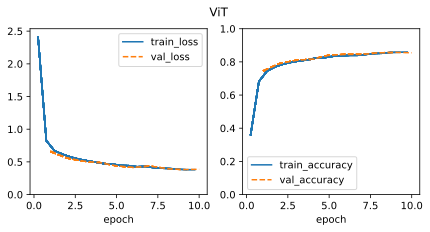

In [15]:
train_model(model, train_dl, val_dl, opt, num_epochs, id="ViT");

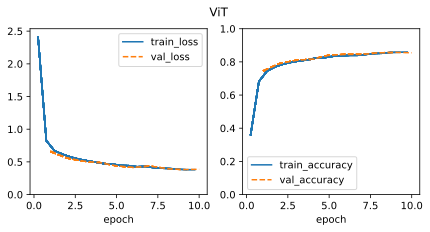

In [16]:
plt.show()